In [1]:
import pandas as pd
#los datos proceden de una biblioteca del curso MOOC de ML de la UGR
gene_exp_inmune=pd.read_csv('https://drive.google.com/uc?id=1PYzEIdmnfjOnBpPDIFBE9hL1Lkj_OBCk', index_col=0)
clinical_info_inmune=pd.read_csv('https://drive.google.com/uc?id=1hHQfcvrFa5Jds-9tW_X4sHjKpYKdii9s', index_col=0)
X, y = gene_exp_inmune, clinical_info_inmune
X.head() #Me sirve para comprobar que se han cargado los datos correctamente

,COL2A1,RXRG,CCL19,SSX1,CST2,PRSS33,CDH2,SCUBE2,TMPRSS13,TRPM8,...,UBASH3A,GBP4,PRF1,PTK6,PCDHB2,GSDMA,DIO2,PLIN1,NCF1C,SLC7A11
0,-1.431141,-7.845756,0.665118,-1.409304,-2.537396,-1.676281,1.529957,-0.895042,-0.298778,5.091742,...,-0.659997,-1.469602,-0.570793,1.047635,-2.068966,-0.202828,-0.506767,1.285256,-0.901222,2.483020
1,-0.424374,-8.352423,0.386055,-2.846138,-0.685105,0.339787,-3.488043,-0.584982,5.679815,-1.117879,...,0.190202,-0.282190,0.375094,0.261662,3.356282,2.028145,-2.399010,-1.152801,0.662490,-2.914991
2,11.014251,0.415549,-1.633781,0.315442,-0.662332,-0.498761,0.535811,-0.467456,-2.818738,1.731049,...,-0.816305,-0.316202,-1.153745,-2.284201,-1.761597,-0.746975,-2.988195,-1.976877,-1.400889,-2.266779
3,-1.180446,-8.187415,-1.958023,5.061146,-2.603744,-0.666706,0.456460,-4.609624,-1.713164,-3.880876,...,0.214344,-0.327110,0.476764,1.153275,-0.337649,-1.006765,-2.686648,-1.329148,0.055994,-2.652313
4,0.816312,-1.189303,4.837235,4.972176,-2.963715,-2.665721,-0.268042,-1.740607,0.011610,-4.107467,...,3.352734,2.145368,3.358865,-2.324389,-1.741669,0.734312,-1.649316,6.284688,1.450729,1.131275


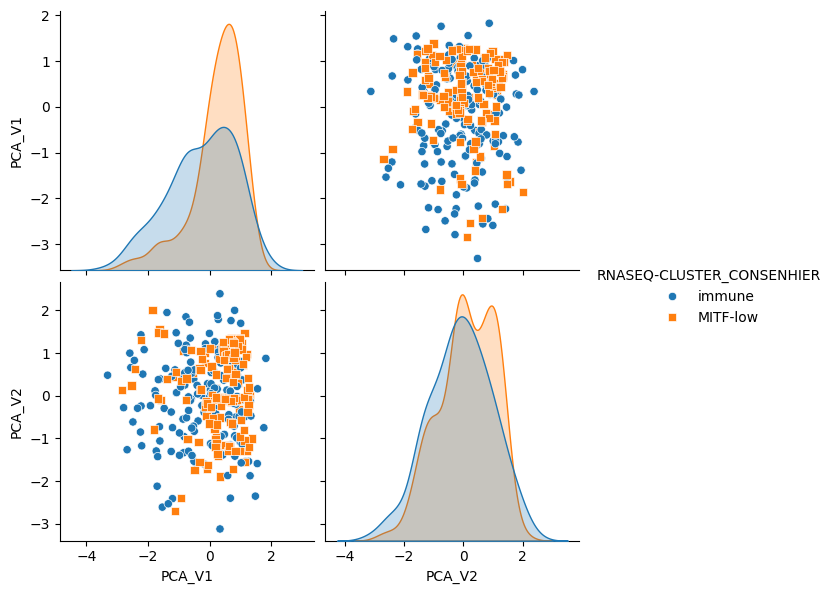

In [2]:
#Transformar el problema en uno de dos dimensiones
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
n_componentes = 2
pca=PCA(n_components=n_componentes)
#Visualizar el problema en dos dimensiones
X_2D=pca.fit_transform(X)
st=StandardScaler()
X_2D=st.fit_transform(X_2D)
df= pd.DataFrame(X_2D, columns=['PCA_V1', 'PCA_V2'])
df=df.join(y)
sns.pairplot(df, hue='RNASEQ-CLUSTER_CONSENHIER', markers=["o", "s"], height=3)
plt.show()


In [3]:
#Validación Hold-out
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
y_int = pd.get_dummies(y).iloc[:,0]
X_2D_train, X_2D_test, y_int_train, y_int_test = train_test_split(X_2D, y_int, random_state=42)
print("Número de instancias en el conjunto de entrenamiento: {}; y test: {}".format(len(X_train), len(X_test)))

Número de instancias en el conjunto de entrenamiento: 252; y test: 84


In [4]:
#Visualizar con sintaxis Scikit-learn
from sklearn import linear_model
lm = linear_model.LinearRegression()
y_train_int=pd.get_dummies(y_train).iloc[:,0]
lm.fit(X_train, y_train_int)
print(lm.intercept_)
print(lm.coef_)

0.3371977981689105
[ 0.00062339 -0.01640629  0.05765623 -0.00365438 -0.03219924  0.02831667
  0.02246995  0.02406873  0.04154468  0.0113776   0.03335884  0.02299525
 -0.00375194  0.04292671  0.01228339 -0.01640771  0.03062444 -0.00302422
 -0.02929467  0.00676286 -0.01947947 -0.02999738  0.02491126 -0.0079843
 -0.00937148  0.00456585  0.00615687 -0.01706812 -0.0042064  -0.03262455
 -0.03213231  0.00450434 -0.05782194 -0.02456257  0.0250594  -0.00637356
  0.04990764 -0.00675726 -0.04263797 -0.07777568  0.03133627  0.01415696
 -0.07683601 -0.08607171 -0.01192452  0.02302473  0.06651956 -0.01050754
  0.04608665 -0.00776793]


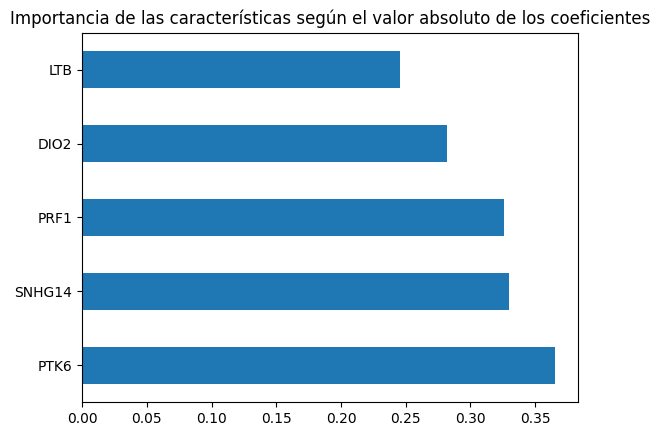

In [5]:
import numpy as np
from sklearn.preprocessing import normalize
importancia = np.abs(lm.coef_)
importancia_norm = normalize(importancia[:,np.newaxis], axis=0).ravel()

#Visualizar la importancia según el valor absoluto de los coeficientes
pd.Series(importancia_norm, index=X_train.columns).nlargest(5).plot(kind='barh')
plt.title('Importancia de las características según el valor absoluto de los coeficientes')
plt.show()

In [6]:
#Consideramos cada clase como valor entero
from sklearn.metrics import accuracy_score
y_test_int = pd.get_dummies(y_test).iloc[:,0]
y_pred = lm.predict(X_test)
y_pred[y_pred >= 0.5] = 1
y_pred[y_pred < 0.5] = 0
print (y_pred[:10])
acc_score = accuracy_score(y_test_int, y_pred)
print("Precisión obtenida: {:.2f}%".format(acc_score*100))

[1. 0. 1. 1. 0. 1. 1. 1. 0. 0.]
Precisión obtenida: 71.43%


In [7]:
#Visualizar con sintaxis Scikit-learn un árbol de decisión
from sklearn import tree
dt = tree.DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
acc_score = accuracy_score(y_test, y_pred)
print("Score de DT obtenido en la partición de test: {:.2f}%".format(acc_score*100))

Score de DT obtenido en la partición de test: 76.19%


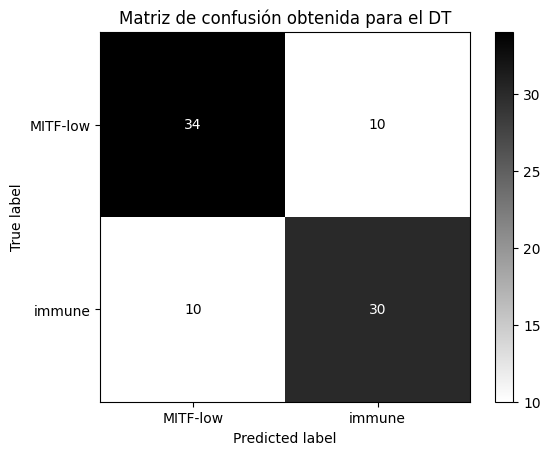

              precision    recall  f1-score   support

    MITF-low       0.77      0.77      0.77        44
      immune       0.75      0.75      0.75        40

    accuracy                           0.76        84
   macro avg       0.76      0.76      0.76        84
weighted avg       0.76      0.76      0.76        84

F1-score obtenido con el DT: 75.00%
AUC obtenido con el DT: 76.14%


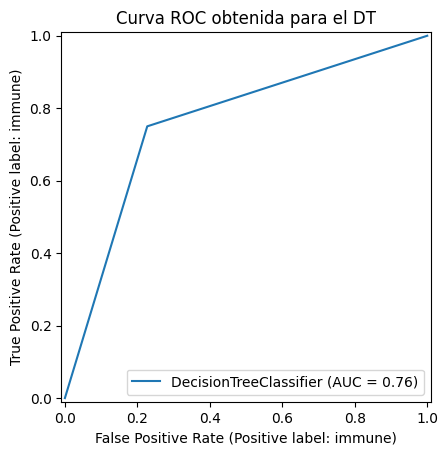

In [8]:
#Repetimos las mismas métricas que en problemas anteriores
from sklearn import metrics
metrics.ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test, cmap='binary')
plt.title("Matriz de confusión obtenida para el DT")
plt.show()

print(metrics.classification_report(y_test, y_pred))
f1 = metrics.f1_score(y_test, y_pred, pos_label='immune')
print("F1-score obtenido con el DT: {:.2f}%".format(f1*100))

y_probs = dt.predict_proba(X_test)
auc = metrics.roc_auc_score(y_test, y_probs[:,1])
print("AUC obtenido con el DT: {:.2f}%".format(auc*100))

metrics.RocCurveDisplay.from_estimator(dt, X_test, y_test)
plt.title("Curva ROC obtenida para el DT")
plt.show()



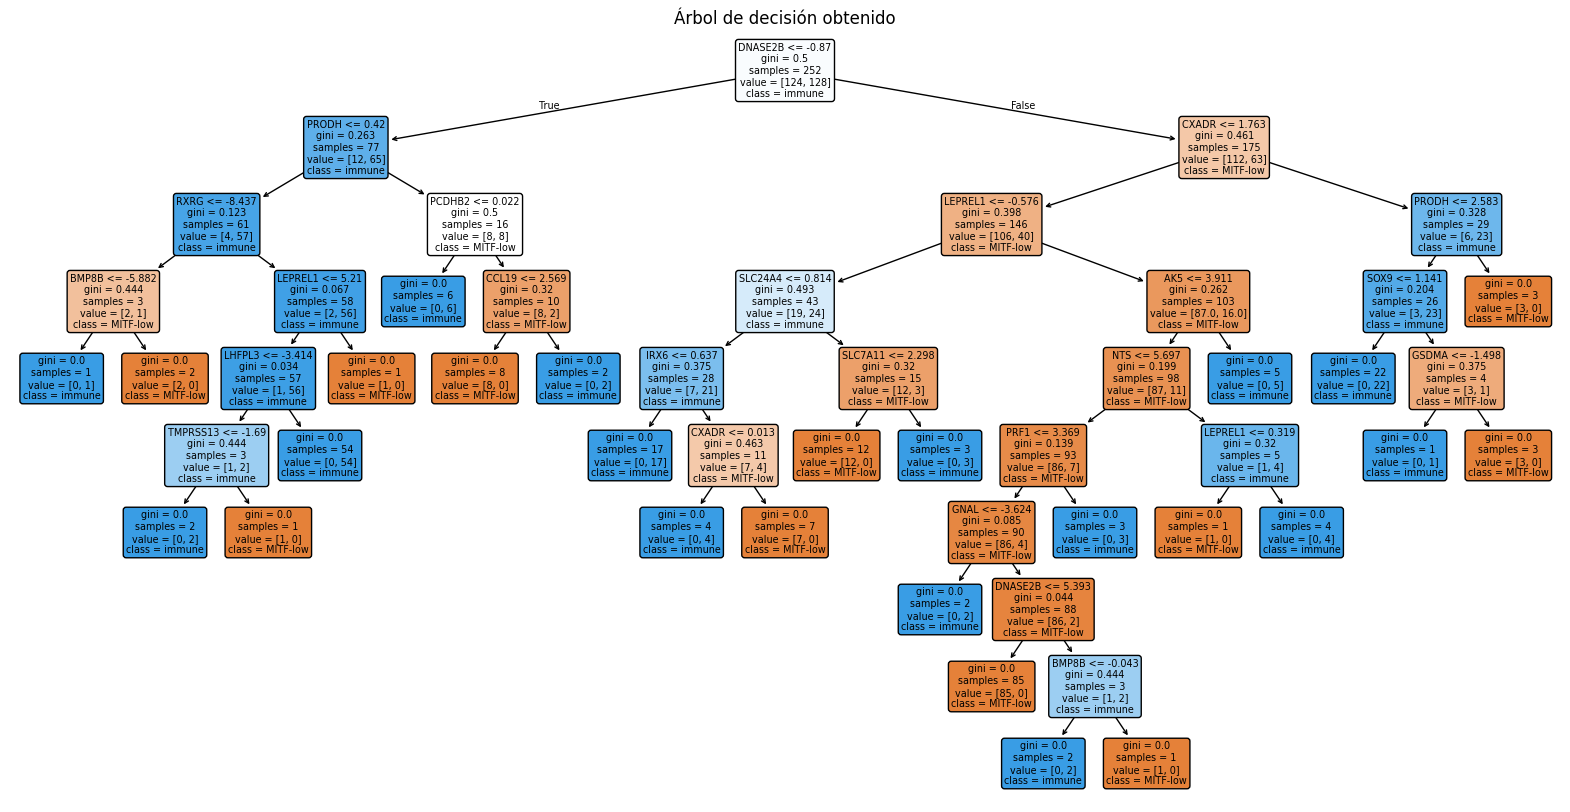

In [9]:
#Visualizar con sintaxis Scikit-learn el DT
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X_train.columns,
          class_names=dt.classes_.astype(str),
          filled=True, rounded=True)
plt.title("Árbol de decisión obtenido")
plt.show()

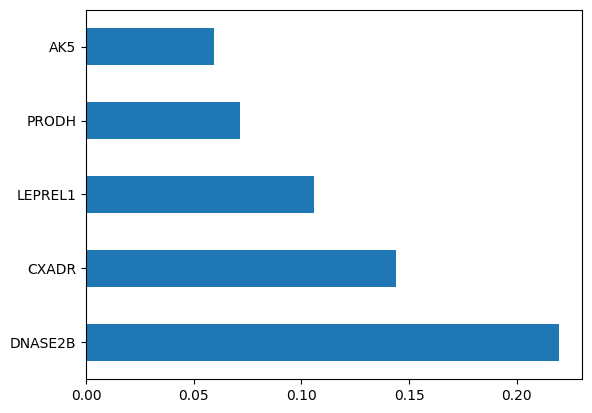

In [10]:
#El propio árbol nos indica las variables más importantes, que son las que aparecen
# en los primeros niveles, cerca de la "raíz" del árbol.
# Lo podemos comprobar con el método feature_importances_
importancia_dt = dt.feature_importances_
pd.Series(importancia_dt, index=X_train.columns).nlargest(5).plot(kind='barh')
plt.show()

<Figure size 800x600 with 0 Axes>

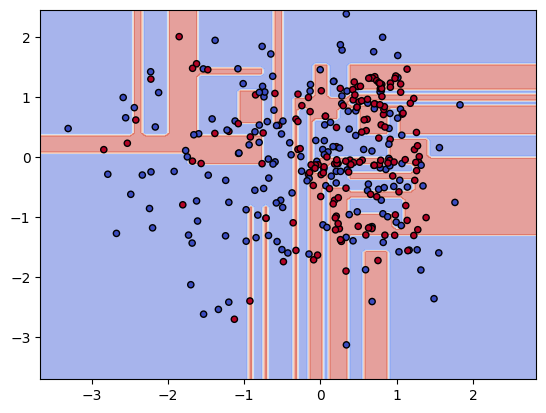

In [19]:
#Comprobamos que coinciden las variables más importantes según el árbol y según el método usado.
#Además, podemos realizar la frontera de decisión del arbol con datos en 2 dimensiones.
from sklearn.inspection import DecisionBoundaryDisplay
clf = tree.DecisionTreeClassifier()
clf.fit(X_2D_train, y_int_train)
score = clf.score(X_2D_test, y_int_test)
fig = plt.figure(figsize=(8,6))

disp = DecisionBoundaryDisplay.from_estimator(clf, X_2D_test, 
                                              response_method='predict', 
                                              alpha=0.5, cmap='coolwarm')
disp.ax_.scatter(X_2D[:,0], X_2D[:,1], c=y_int, edgecolor="k", s=20,cmap='coolwarm')
plt.show()